# Outlier Analysis

This notebook analyzes numerical features across the cleaned Olist datasets to identify potential outliers.

The objective is to detect unusually large or small observations, understand their business significance, and determine whether any preprocessing is required before feature engineering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Define Dataset Location

Load the cleaned datasets generated during the previous data cleaning stage.

In [2]:
INTERIM_DATA_DIR = Path("../data/interim/olist")

## Load Cleaned Dataset Tables

Load all cleaned datasets from the interim directory for statistical analysis.

In [3]:
datasets = {
    "customers": pd.read_csv(INTERIM_DATA_DIR / "olist_customers_dataset.csv"),
    "orders": pd.read_csv(INTERIM_DATA_DIR / "olist_orders_dataset.csv"),
    "order_items": pd.read_csv(INTERIM_DATA_DIR / "olist_order_items_dataset.csv"),
    "payments": pd.read_csv(INTERIM_DATA_DIR / "olist_order_payments_dataset.csv"),
    "products": pd.read_csv(INTERIM_DATA_DIR / "olist_products_dataset.csv"),
    "reviews": pd.read_csv(INTERIM_DATA_DIR / "olist_order_reviews_dataset.csv"),
    "sellers": pd.read_csv(INTERIM_DATA_DIR / "olist_sellers_dataset.csv"),
    "geolocation": pd.read_csv(INTERIM_DATA_DIR / "olist_geolocation_dataset.csv"),
    "category_translation": pd.read_csv(
        INTERIM_DATA_DIR / "product_category_name_translation.csv"
    ),
}

## Identify Numerical Features

Extract numerical columns from each dataset. Only numerical variables are considered for outlier analysis.

In [4]:
for name, df in datasets.items():

    numeric_columns = df.select_dtypes(include="number").columns.tolist()

    print(f"\n{name.upper()}")
    print(numeric_columns)


CUSTOMERS
['customer_zip_code_prefix']

ORDERS
[]

ORDER_ITEMS
['order_item_id', 'price', 'freight_value']

PAYMENTS
['payment_sequential', 'payment_installments', 'payment_value']

PRODUCTS
['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

REVIEWS
['review_score']

SELLERS
['seller_zip_code_prefix']

GEOLOCATION
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']

CATEGORY_TRANSLATION
[]


## Statistical Summary

Generate descriptive statistics for every numerical feature to understand the distribution of values.

In [5]:
for name, df in datasets.items():

    numeric_df = df.select_dtypes(include="number")

    if numeric_df.empty:
        continue

    print(f"\n{name.upper()}")

    display(numeric_df.describe().T)


CUSTOMERS


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0



ORDER_ITEMS


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68



PAYMENTS


...

,count,mean,std,min,25%,50%,75%,max
review_score,99224.0,4.086421,1.347579,1.0,4.0,5.0,5.0,5.0



SELLERS


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0



GEOLOCATION


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,738332.0,38316.086800,30632.496675,1001.000000,12600.000000,29144.000000,65950.000000,99990.000000
geolocation_lat,738332.0,-20.998353,5.892315,-36.605374,-23.603061,-22.873588,-19.923336,45.065933
geolocation_lng,738332.0,-46.461098,4.393705,-101.466766,-48.867822,-46.647278,-43.836974,121.105394


## Detect Outliers Using IQR

Calculate the number of outliers in each numerical column using the Interquartile Range (IQR) method.

In [6]:
outlier_summary = []

for dataset_name, df in datasets.items():

    numeric_df = df.select_dtypes(include="number")

    for column in numeric_df.columns:

        Q1 = numeric_df[column].quantile(0.25)
        Q3 = numeric_df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = numeric_df[
            (numeric_df[column] < lower) |
            (numeric_df[column] > upper)
        ]

        outlier_summary.append({
            "Dataset": dataset_name,
            "Column": column,
            "Outliers": len(outliers),
            "Percentage": round(len(outliers) / len(df) * 100, 2)
        })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by="Percentage",
    ascending=False
)

,Dataset,Column,Outliers,Percentage
17,geolocation,geolocation_lat,130286,17.65
14,reviews,review_score,14575,14.69
10,products,product_weight_g,4551,13.81
1,order_items,order_item_id,13984,12.41
3,order_items,freight_value,12134,10.77
6,payments,payment_value,7981,7.68
2,order_items,price,8427,7.48
8,products,product_description_lenght,2078,6.31
5,payments,payment_installments,6313,6.08
12,products,product_height_cm,1892,5.74


## Visualize Outliers

Generate boxplots for numerical features to visually inspect the distribution and identify potential extreme observations.

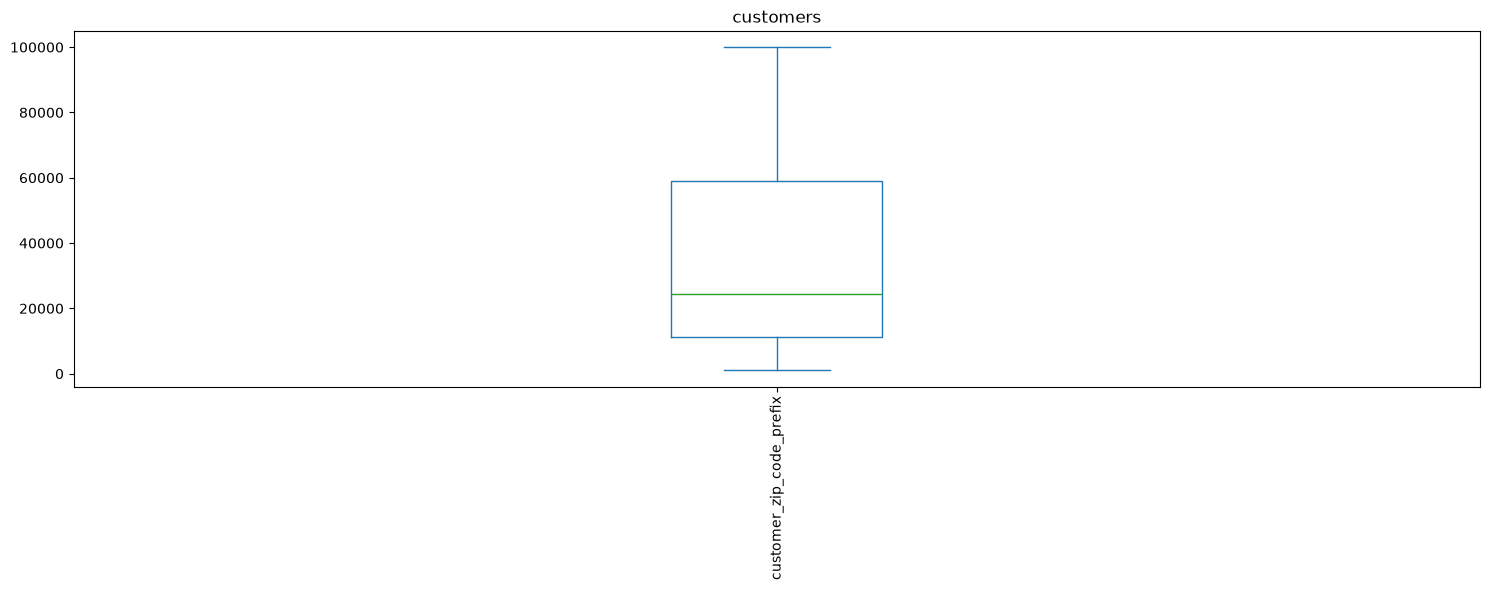

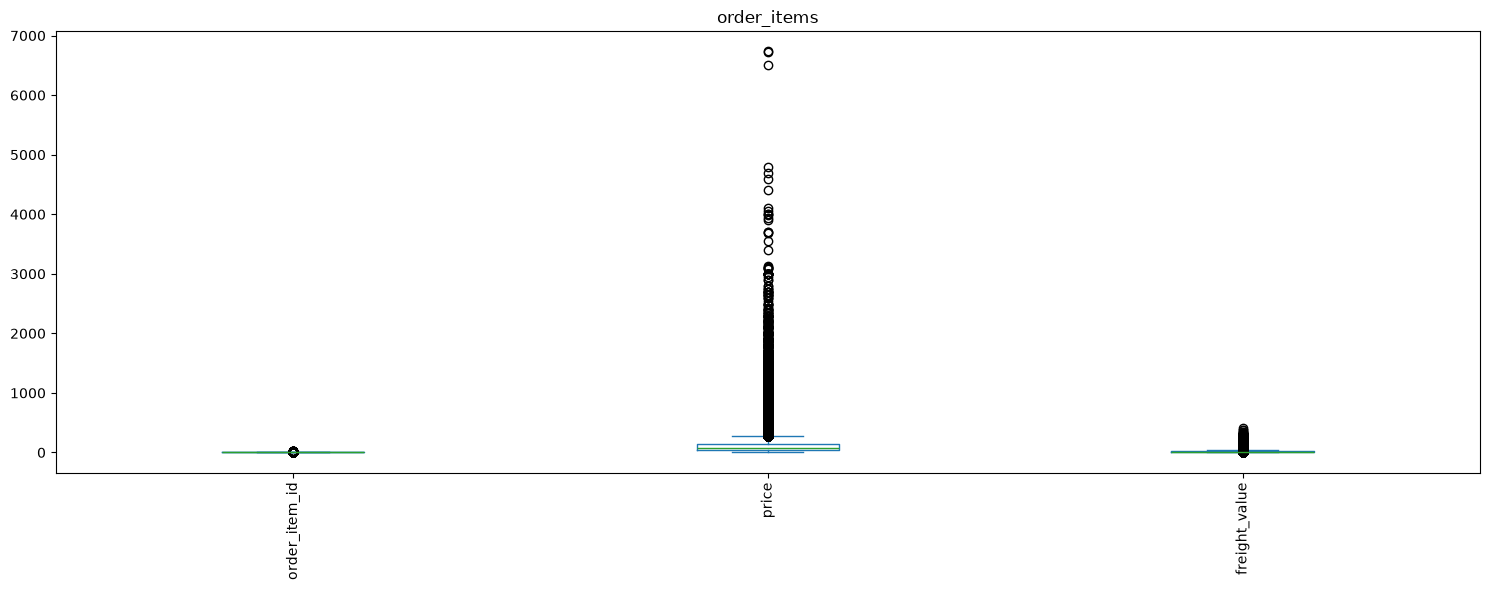

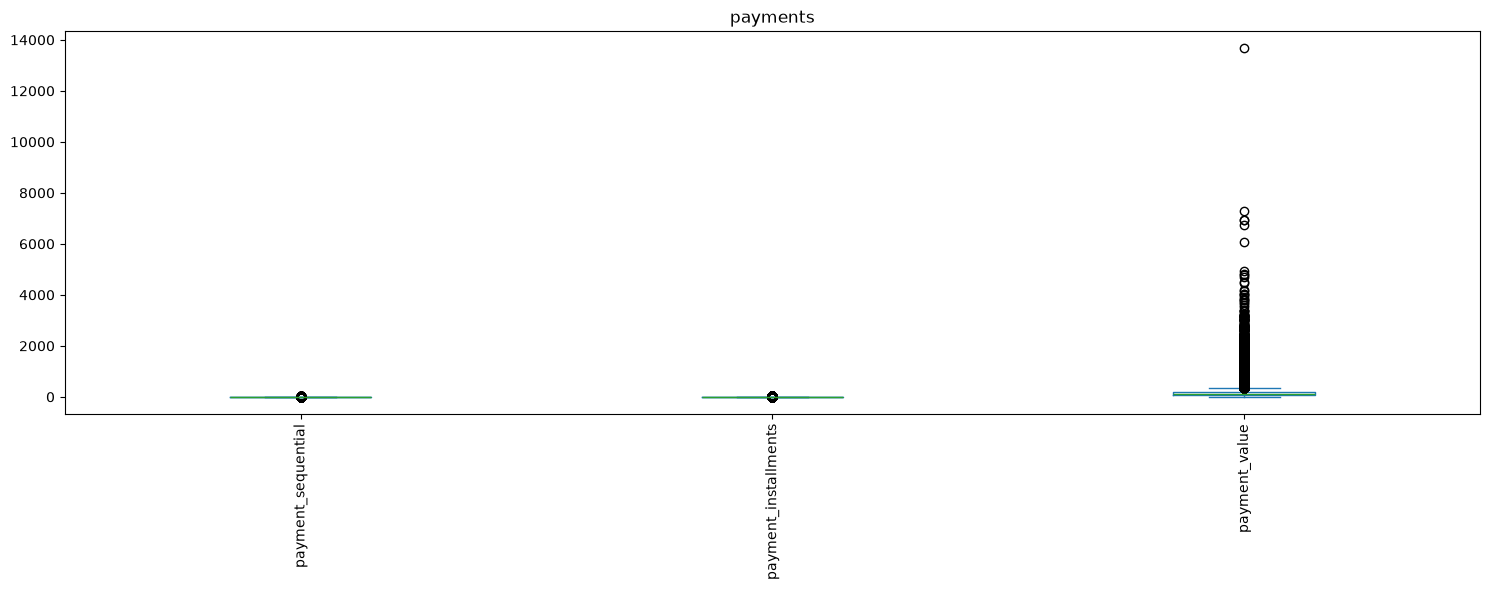

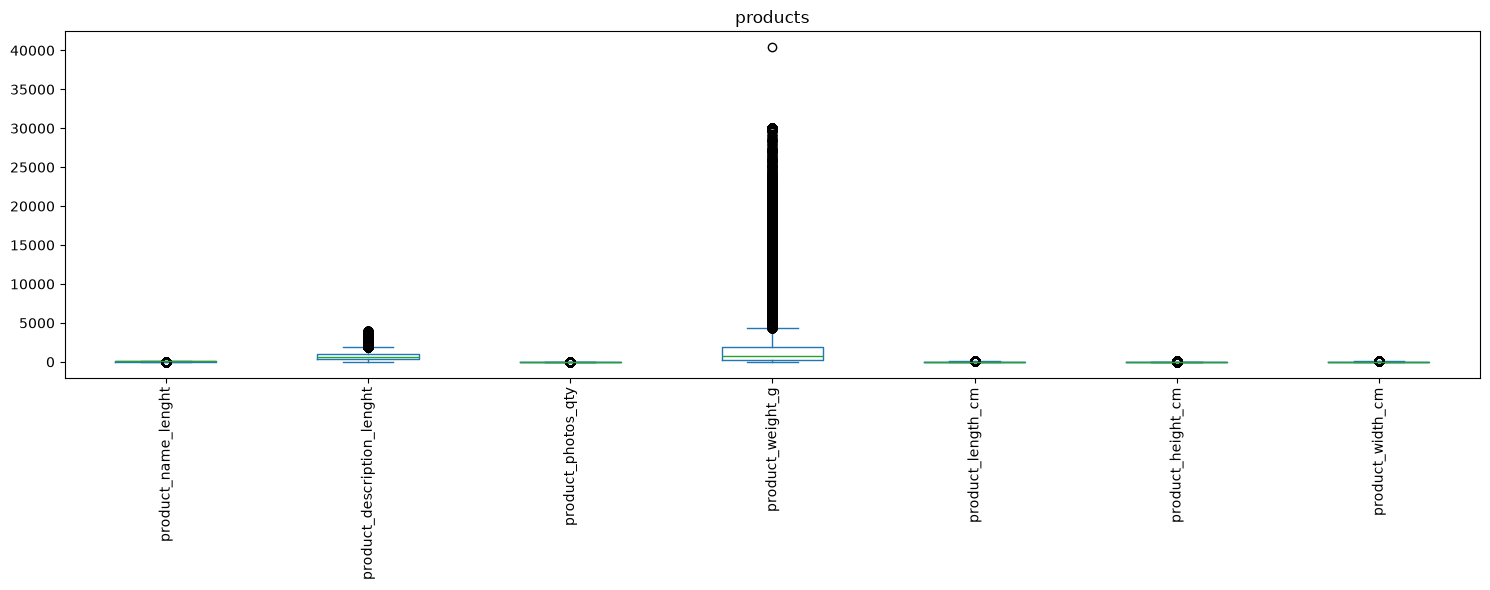

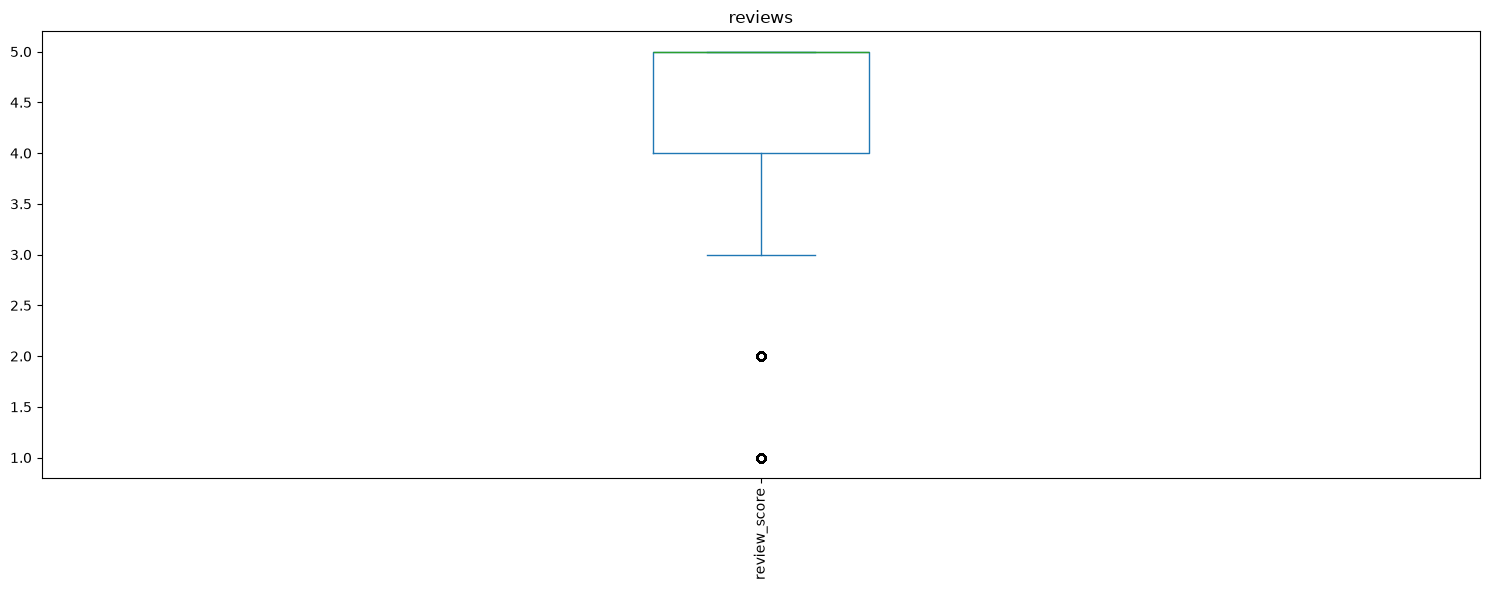

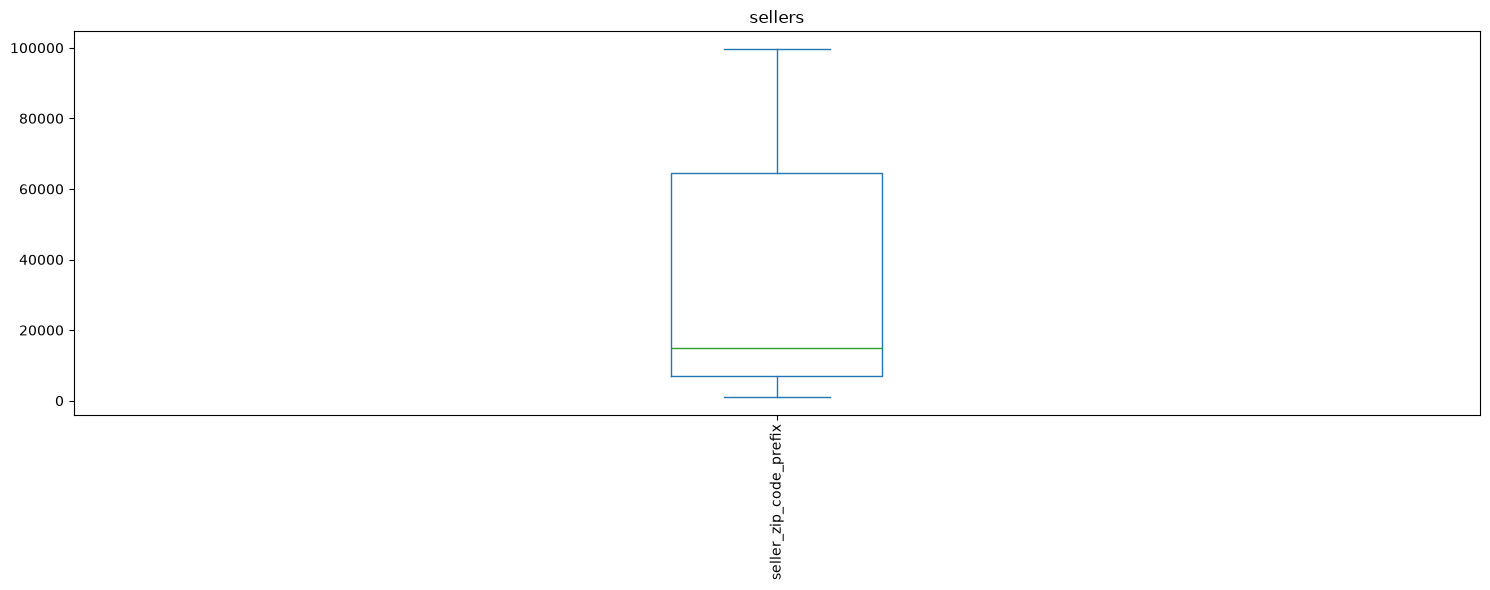

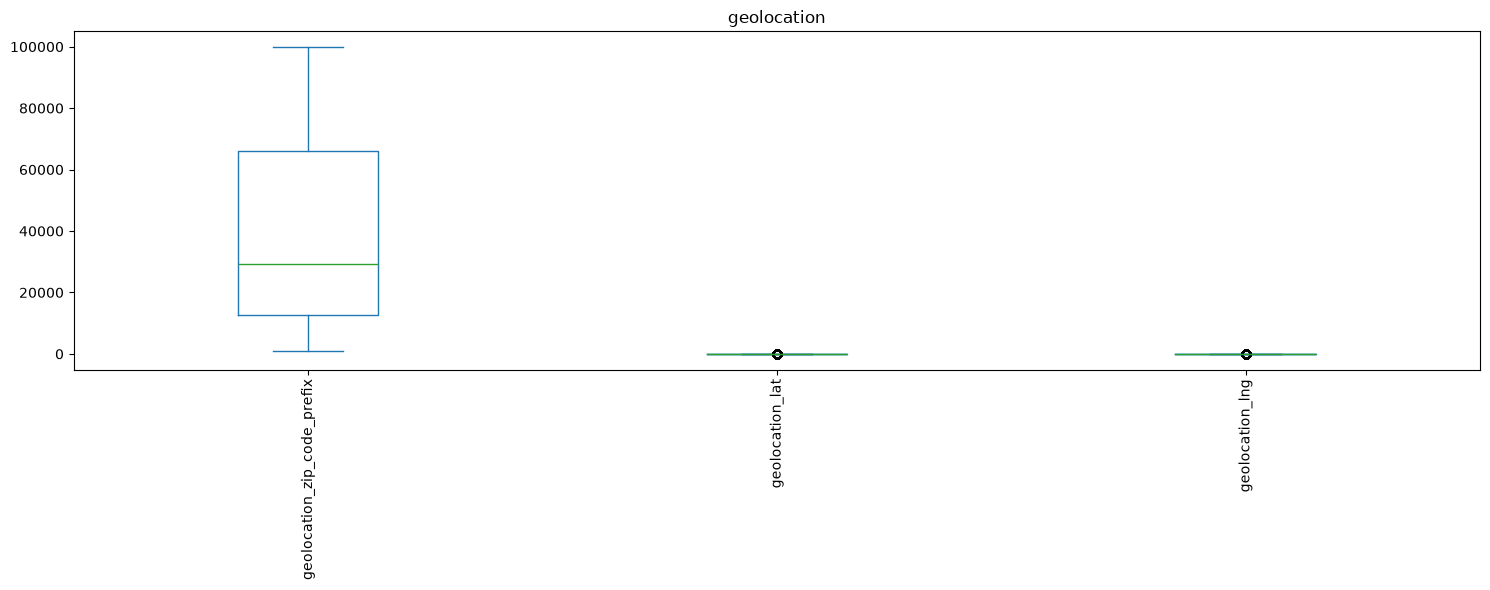

In [7]:
for dataset_name, df in datasets.items():

    numeric_df = df.select_dtypes(include="number")

    if numeric_df.empty:
        continue

    numeric_df.plot(
        kind="box",
        figsize=(15, 6),
        rot=90
    )

    plt.title(dataset_name)

    plt.tight_layout()

    plt.show()

## Conclusion

This notebook identified numerical outliers using statistical and visual methods.

The detected observations will be reviewed from a business perspective before deciding whether they should be retained, transformed, or excluded during feature engineering.